# Why Do We Divide by n - 1? A Visual Proof of Bessel's Correction

When you compute the variance of a **sample** and want it to estimate the variance of the **population** it came from, the textbooks would always tell us to divide by `n - 1` instead of `n`:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2
$$

For years I memorized this rule, but never took time to understand the *why* behind it, until now.

This is called **Bessel's Correction**, and in this notebook I will build up the intuition of why we use it, from scratch. Nothing is taken on faith, and everything is proved out.

My approach is the following:
1. **Set up the target** - build a small population and compute its *true* variance.
2. **Generate every possible sample** - and compute variance two competing ways.
3. **Visualize the bias** - see, numerically and visually, that dividing by `n` systematically gets it wrong.
4. **Prove the mean minimizes squared deviations** - explain the mechanism that *causes* the bias.
5. **Explain degrees of freedom** - the actual mechanism behind why `n - 1` fixes it.

By the end, `n - 1` should feel inevitable rather than arbitrary.

*Note: I wrote this notebook from scratch and then leveraged AI to verify my statements and polish my presentation. The whole point of this exercise was to struggle with the material and eventually arrive at a point where I can teach it. Having and LLM simply build this would have completely defeated the purpose. I encourage everyone to use AI judiciously.*

## Part 1 - Setting Up the Target

Before we can talk about estimating a variance, we need to create a full population to estimate. In practice we never get to see the whole population - that's exactly why we sample. But to study how good an estimator is, we get to cheat: build a tiny population, compute its **true** variance directly, and then check how well samples estimate it.

We'll use a relatively small population of 50 values drawn from a normal distribution. Everything downstream - every sample, every estimate - will be judged against the population variance. This will serve as our target.

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
import polars as pl # I normally use Pandas, but Polars is more memory efficient

C:\Users\cisan\AppData\Roaming\Python\Python311\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
pop_size = 50
rng_pop = np.random.default_rng(7)
pop_data = np.round(rng_pop.normal(loc=5, scale=20, size=pop_size)).astype(int)


pop_mean = np.mean(pop_data)
pop_var = np.var(pop_data)

print(f"Population (N={pop_size}): {pop_data}")
print(f"Population mean:     {pop_mean:.2f}")
print(f"Population variance: {pop_var:.2f}   <-- this number is our target!")

Population (N=50): [  5  11   0 -13  -4 -15   6  32  -5  -7  15  12   7 -14   4  19 -22  -4
 -33 -21 -32   0 -20  10   8   1 -45  -6   4   7 -26  -5 -15 -11  26 -11
   4  23  -7   3   7   6 -20   7  32 -26  22   7  -8  45]
Population mean:     -0.94
Population variance: 313.70   <-- this number is our target!


A quick vocabulary check, because the notation matters for everything that follows:

| Metric | Formula | What it means |
|---|---|---|
| Population variance ($\sigma^2$ ) | $$\frac{1}{N}\sum(x_i - \mu)^2$$ | The true variance (our target) |
| Sample variance (naive) | $$\frac{1}{n}\sum(x_i - \bar{x})^2$$ | What you'd guess if you just copied the population formula (divide by n)|
| Sample variance (corrected) ($s^2$) | $\frac{1}{n-1}\sum(x_i - \bar{x})^2$ | Bessel's correction (divide by n) - better estimator |

The population variance uses population size `N` as the denominator. When we only have a *sample* of the population, should we divide by sample size `n`, or `n-1`? Why? This is what we seek to answer in this notebook.

## Part 2 - Every Possible Sample + Two Variance Formulas

Here is where we conduct the experiment. Instead of drawing a handful of random samples and hoping they're representative, we enumerate *every possible sample* of `n = 4` from our population of 8. In this case there are only $\binom{50}{4} = 230{,}300$ of them. I intentionally kept the population small for this reason, as the number of combinations is still manageable and not memory intensive.

Enumerating every sample gives us the *exact* sampling distribution of the variance estimate, with no randomness or luck involved.

For each of the 230k samples, we'll compute:
- its mean
- each point's squared deviation from that mean
- the sum of those squared deviations
- variance divided by $n$ (the naive approach)
- variance divided by $n-1$ (Bessel's correction)

In [3]:
n = 4
combos_2d = np.fromiter(itertools.chain.from_iterable(itertools.combinations(pop_data, n)),dtype=np.float64).reshape(-1, n)

print(f"Number of possible samples of size {n} from a population of {pop_size}: {combos_2d.shape[0]}")

Number of possible samples of size 4 from a population of 50: 230300


In [4]:
decimals = 2
means = np.round(np.mean(combos_2d, axis=1), decimals)
sq_devs_2d = np.round((combos_2d - means[:, np.newaxis]) ** 2, decimals)
sum_sq_devs = np.round(np.sum(sq_devs_2d, axis=1), decimals)
div_n = np.round(np.divide(sum_sq_devs,n), decimals)
div_n_minus_1 = np.round(np.divide(sum_sq_devs,(n-1)), decimals)

In [5]:
df = pl.DataFrame({
    "combination": combos_2d,            # Automatically becomes List(Float64)
    "mean": means,                       # Float64
    "squared_deviations": sq_devs_2d,    # Automatically becomes List(Float64)
    "sum_squared_deviations": sum_sq_devs, # Float64
    "div_n": div_n,                   # Float64
    "div_n_minus_1": div_n_minus_1      # Float64
})

df.head(10)

combination,mean,squared_deviations,sum_squared_deviations,div_n,div_n_minus_1
"array[f64, 4]",f64,"array[f64, 4]",f64,f64,f64
"[5.0, 11.0, … -13.0]",0.75,"[18.06, 105.06, … 189.06]",312.74,78.18,104.25
"[5.0, 11.0, … -4.0]",3.0,"[4.0, 64.0, … 49.0]",126.0,31.5,42.0
"[5.0, 11.0, … -15.0]",0.25,"[22.56, 115.56, … 232.56]",370.74,92.68,123.58
"[5.0, 11.0, … 6.0]",5.5,"[0.25, 30.25, … 0.25]",61.0,15.25,20.33
"[5.0, 11.0, … 32.0]",12.0,"[49.0, 1.0, … 400.0]",594.0,148.5,198.0
"[5.0, 11.0, … -5.0]",2.75,"[5.06, 68.06, … 60.06]",140.74,35.18,46.91
"[5.0, 11.0, … -7.0]",2.25,"[7.56, 76.56, … 85.56]",174.74,43.68,58.25
"[5.0, 11.0, … 15.0]",7.75,"[7.56, 10.56, … 52.56]",130.74,32.68,43.58
"[5.0, 11.0, … 12.0]",7.0,"[4.0, 16.0, … 25.0]",94.0,23.5,31.33


Each row is a possible sample of 4 values out of our population of 8, with both candidate variance formulas in the last two columns. Observe how `div_n_minus_1` is consistently higher than `div_n` for each sample.

Let's summarize across all 70 samples.

In [6]:
df.describe()

statistic,combination,mean,squared_deviations,sum_squared_deviations,div_n,div_n_minus_1
str,f64,f64,f64,f64,f64,f64
"""count""",230300.0,230300.0,230300.0,230300.0,230300.0,230300.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,-0.94,null,960.290109,240.07003,320.096934
"""std""",null,8.580381,null,786.072164,196.51804,262.023992
"""min""",null,-34.0,null,0.0,0.0,0.0
"""25%""",null,-6.75,null,378.0,94.5,126.0
"""50%""",null,-1.0,null,746.74,186.68,248.91
"""75%""",null,4.75,null,1350.0,337.5,450.0
"""max""",null,33.75,null,6162.74,1540.68,2054.25


In [7]:
div_n_avg = np.round(np.mean(div_n), decimals)
div_n_minus_1_avg = np.round(np.mean(div_n_minus_1), decimals)

print(f"True population variance:                    {pop_var:.2f}")
print(f"Average of (divide-by-n)     across samples:  {div_n_avg:.2f}")
print(f"Average of (divide-by-n-1)   across samples:  {div_n_minus_1_avg:.2f}")
print()
print(f"divide-by-n error:     {div_n_avg - pop_var:+.2f}")
print(f"divide-by-n-1 error:   {div_n_minus_1_avg - pop_var:+.2f}")

True population variance:                    313.70
Average of (divide-by-n)     across samples:  240.07
Average of (divide-by-n-1)   across samples:  320.10

divide-by-n error:     -73.63
divide-by-n-1 error:   +6.40


Averaged over **every single possible sample**, `divide-by-n` lands below the true population variance, while `divide-by-n-1` lands much closer to it. That's the definition of *bias*: the average value of an estimator across all possible samples, compared to the truth it's estimating. Divide-by-n is a **biased** estimator - it doesn't just miss sometimes, it misses in the same direction *every time on average*. Divide-by-n-1 is **unbiased**.

We will explain why the bias exists in a bit; but first, let's get a better visual of the phenomenon.

## Part 3 - Visualizing the Bias

Numbers in a printout are convincing, but seeing the full distribution of estimates makes the systematic nature of the bias unmistakable. Below are two views of the same samples: an overlaid histogram of the two estimators, and a side-by-side comparison of their spread.

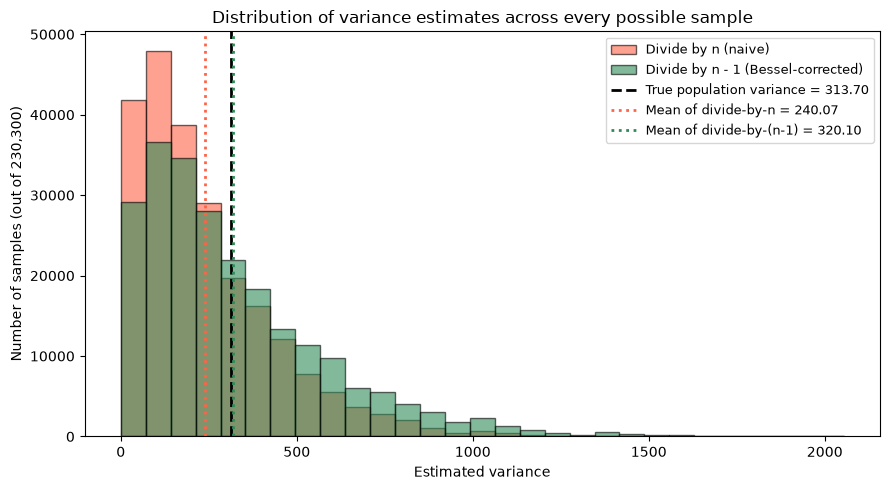

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(min(div_n.min(), div_n_minus_1.min()),max(div_n.max(), div_n_minus_1.max()), 30)

ax.hist(div_n, bins=bins, alpha=0.6, color="tomato", edgecolor="black",label="Divide by n (naive)")
ax.hist(div_n_minus_1, bins=bins, alpha=0.6, color="seagreen", edgecolor="black",label="Divide by n - 1 (Bessel-corrected)")

ax.axvline(pop_var, color="black", linestyle="--", linewidth=2,label=f"True population variance = {pop_var:.2f}")
ax.axvline(div_n_avg, color="tomato", linestyle=":", linewidth=2,label=f"Mean of divide-by-n = {div_n_avg:.2f}")
ax.axvline(div_n_minus_1_avg, color="seagreen", linestyle=":", linewidth=2,label=f"Mean of divide-by-(n-1) = {div_n_minus_1_avg:.2f}")

ax.set_xlabel("Estimated variance")
ax.set_ylabel(f"Number of samples (out of {len(combos_2d):,})")
ax.set_title("Distribution of variance estimates across every possible sample")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The naive (divide-by-n) distribution is shifted noticeably left of the true population variance. Every one of its samples is systematically smaller than it should be, not just a few unlucky ones. The corrected distribution is centered much closer to the true population variance (the black dashed line). That's bias made visible: not scatter, but a consistent lean in one direction.

You will see this leftward bias with virtually any population that you run this experiment on. Feel free to change or remove the seed and rerun this experiment with a completely different population.

The next view makes the *pairing* explicit - for the same samples, how do the two estimators compare side by side?

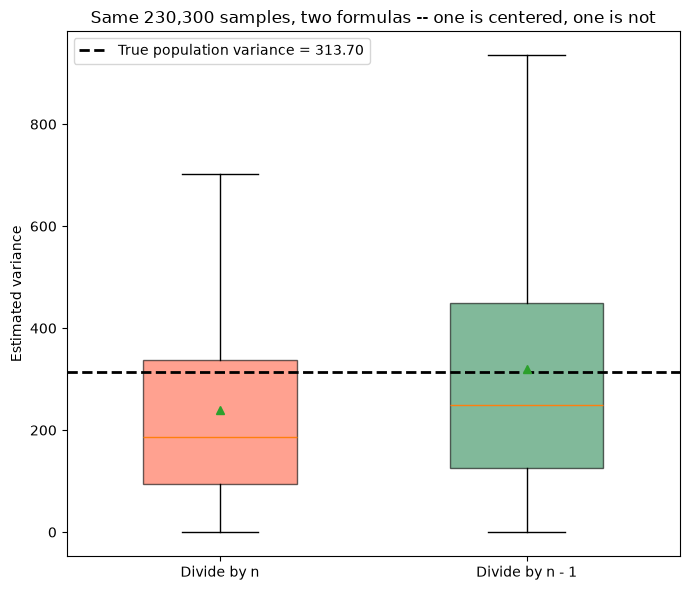

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

box_data = [div_n, div_n_minus_1]
bp = ax.boxplot(box_data, tick_labels=["Divide by n", "Divide by n - 1"],
                patch_artist=True, widths=0.5, showmeans=True, showfliers=False)

for patch, color in zip(bp["boxes"], ["tomato", "seagreen"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(pop_var, color="black", linestyle="--", linewidth=2,
           label=f"True population variance = {pop_var:.2f}")

ax.set_ylabel("Estimated variance")
ax.set_title(f"Same {len(combos_2d):,} samples, two formulas -- one is centered, one is not")
ax.legend()
plt.tight_layout()
plt.show()

The green triangles (means) mark where each estimator lands on average. Divide-by-n's mean sits below the true variance line - not from bad luck on any particular sample, but as a structural property of the formula itself, one that would show up again if we reran this whole experiment on a different population. So where does this systematic undershoot actually come from?

The answer traces back to a property of the sample mean we haven't examined yet: it isn't just *a* center for a sample, it's the *specific* point that makes that sample's own spread look as small as mathematically possible. That's worth proving directly - and once we do, the bias above stops being a mystery and becomes an algebraic certainty.

## Part 4 - Why the Mean? The Mechanism Behind the Bias

Every variance formula centers data on its mean before squaring, and that's not an arbitrary choice. The mean is specifically the value that **minimizes the sum of squared deviations** for whatever data it's computed from. No other center does better - not even the *true* population mean, when judged against a given sample's own sum of squared deviations.

This is the direct cause of the bias we just saw in Part 3: because each sample's mean is custom-fit to minimize that sample's own spread, the sum of squared deviations computed around it will always be less than or equal to the sum of squared deviations computed around the true population mean. The naive estimator doesn't just happen to undershoot - it's built from a quantity that was mathematically guaranteed, for every single sample, to be as small as it could possibly be.

Let's prove the minimization property first, then use it to explain the bias directly.

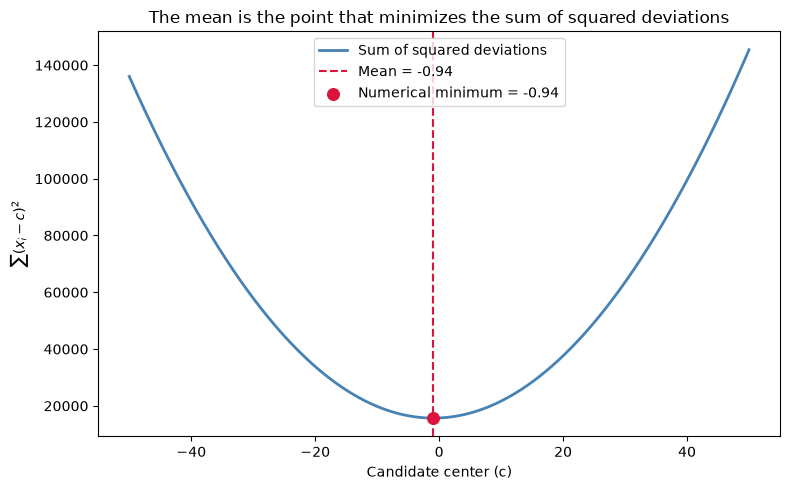

Numerically found minimum at c = -0.939
Actual mean               at   = -0.940


In [10]:
def sum_sq_dev(data, center):
    """Sum of squared deviations of `data` from a candidate `center`."""
    return np.sum((data - center) ** 2)

pad = 5
candidates = np.linspace(pop_data.min() - pad, pop_data.max() + pad, 60000)
ssd_values = [sum_sq_dev(pop_data, c) for c in candidates]

best_idx = np.argmin(ssd_values)
best_candidate = candidates[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(candidates, ssd_values, color="steelblue", linewidth=2, label="Sum of squared deviations")
ax.axvline(pop_mean, color="crimson", linestyle="--", linewidth=1.5, label=f"Mean = {pop_mean:.2f}")
ax.scatter([best_candidate], [ssd_values[best_idx]], color="crimson", zorder=5, s=70,
           label=f"Numerical minimum = {best_candidate:.2f}")

ax.set_xlabel("Candidate center (c)")
ax.set_ylabel(r"$\sum (x_i - c)^2$")
ax.set_title("The mean is the point that minimizes the sum of squared deviations")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Numerically found minimum at c = {best_candidate:.3f}")
print(f"Actual mean               at   = {pop_mean:.3f}")

*Note: I was initially planning to stop Part 4 here, as my goal of this notebook was to make this explanation as visual and intuitive as possible. However, Claude suggested that I add the mathematical proofs to why the mean is where the sum of squared deviations is minimized. I decided to take this suggestion, as it takes the notebook past visual affirmation, and proves the property with mathematical precision. It is a bit dense, but a worthy supporting documentation.*

The curve is a parabola, and its bottom lands exactly on the mean - every time, for any dataset. If you've done some calculus, this probably looks familiar: minimizing a smooth curve like this is a classic derivative-equals-zero problem, and that's exactly what's happening under the hood - differentiate $\sum(x_i-c)^2$ with respect to $c$, set it to zero, and solve. If you'd like to see that worked out in full (including confirming it's a minimum and not a maximum), [this walkthrough](https://matthew-brett.github.io/cfd2019/chapters/extra/mean_sq_deviations) does exactly that.

We don't need calculus to prove it, though - everything here follows from algebra. Start with a small trick: add and subtract the sample mean $\bar{x}$ inside the parentheses. Nothing has changed yet, but it sets up a useful expansion:

$$
x_i - c = (x_i - \bar{x}) + (\bar{x} - c)
$$

Square both sides and sum over all $n$ points:

$$
\sum (x_i - c)^2 = \sum (x_i - \bar{x})^2 + 2(\bar{x}-c)\sum(x_i - \bar{x}) + n(\bar{x}-c)^2
$$

The middle term vanishes because $\sum(x_i - \bar{x}) = 0$ always - a quick fact worth confirming on its own: $\sum(x_i - \bar{x}) = \sum x_i - n\bar{x} = \sum x_i - \sum x_i = 0$, since $\bar{x} = \frac{1}{n}\sum x_i$ by definition. (Part 5's waterfall chart makes this same fact vivid and hard to forget.) That leaves:

$$
\sum (x_i - c)^2 = \sum (x_i - \bar{x})^2 + n(\bar{x}-c)^2
$$

In words: the spread around *any* point $c$ equals the spread around the mean, plus a penalty for how far $c$ is from the mean. That penalty is a square, so it's never negative - and it's exactly zero only when $c = \bar{x}$. So the total on the left is smallest exactly when $c$ equals the mean, for *that specific dataset*. No derivatives required.

Now here's the identity that turns this into an explanation for Act 3's bias. Substitute $c = \mu$, the true population mean, into the formula above and rearrange:

$$
\sum (x_i - \bar{x})^2 \;=\; \sum (x_i - \mu)^2 \;-\; n(\bar{x} - \mu)^2
$$

Since $n(\bar{x} - \mu)^2 \geq 0$ always, this says the sum of squared deviations around the sample mean can never exceed the sum of squared deviations around the true mean - and it's strictly smaller unless a sample's mean happens to land exactly on $\mu$. Let's check this on a few actual samples from our table.

In [11]:
demo_indices = [0, 75000, 150000]

for idx in demo_indices:
    sample = combos_2d[idx]
    s_mean = means[idx]
    ssd_sample_mean = sum_sq_devs[idx]
    ssd_pop_mean = np.sum((sample - pop_mean) ** 2)
    predicted_gap = n * (s_mean - pop_mean) ** 2

    print(f"Sample {idx}: {sample.tolist()}")
    print(f"  SSD around its own sample mean ({s_mean:.2f}):  {ssd_sample_mean:.2f}")
    print(f"  SSD around the true population mean ({pop_mean:.2f}): {ssd_pop_mean:.2f}")
    print(f"  Gap: {ssd_pop_mean - ssd_sample_mean:.2f}   (predicted n(x\u0304-\u03bc)\u00b2 = {predicted_gap:.2f})")
    print()

Sample 0: [5.0, 11.0, 0.0, -13.0]
  SSD around its own sample mean (0.75):  312.74
  SSD around the true population mean (-0.94): 324.17
  Gap: 11.43   (predicted n(x̄-μ)² = 11.42)

Sample 75000: [-4.0, 19.0, 8.0, 7.0]
  SSD around its own sample mean (7.50):  265.00
  SSD around the true population mean (-0.94): 549.93
  Gap: 284.93   (predicted n(x̄-μ)² = 284.93)

Sample 150000: [12.0, 19.0, -4.0, -26.0]
  SSD around its own sample mean (0.25):  1196.74
  SSD around the true population mean (-0.94): 1202.41
  Gap: 5.67   (predicted n(x̄-μ)² = 5.66)



For every sample, the sum of squared deviations around its own mean comes in lower than around the true population mean, and the size of that gap matches $n(\bar{x} - \mu)^2$ exactly. This isn't a coincidence of these three rows; it holds for every sample, so let's confirm it in aggregate.

In [12]:
ssd_pop_mean_all = np.sum((combos_2d - pop_mean) ** 2, axis=1)
gap_actual = np.mean(ssd_pop_mean_all - sum_sq_devs)
gap_predicted = n * np.mean((means - pop_mean) ** 2)

print(f"Average gap across all {len(combos_2d):,} samples:            {gap_actual:.2f}")
print(f"Predicted (n x average squared distance of x\u0304 from \u03bc): {gap_predicted:.2f}")

Average gap across all 230,300 samples:            294.50
Predicted (n x average squared distance of x̄ from μ): 294.49


That's the mechanism. Every sample in Part 3 had its sum of squared deviations computed around a mean that was specifically chosen to make that number as small as it could be - so summing those minimized values and dividing by $n$ will, on average, undercount the population's true spread. The naive estimator isn't broken by chance; it's the same optimization playing out across every sample.

What's left is to quantify *exactly* how much smaller - not just directionally, but by precisely how much - so we know precisely what correction to apply. That's degrees of freedom, next.

## Part 5 - Degrees of Freedom: Quantifying the Correction

We now know *why* divide-by-n undershoots. Here's the mechanism that tells us *how much* to correct for it.

When you compute deviations from the **sample mean** (rather than the true population mean), those deviations are not free to be anything - they are mathematically forced to sum to exactly zero:

$$
\sum_{i=1}^n (x_i - \bar{x}) = \sum x_i - n\bar{x} = \sum x_i - \sum x_i = 0
$$

That's not an approximation - it's an algebraic identity, true for every possible sample, every time. Let's confirm it on one actual sample from our table.

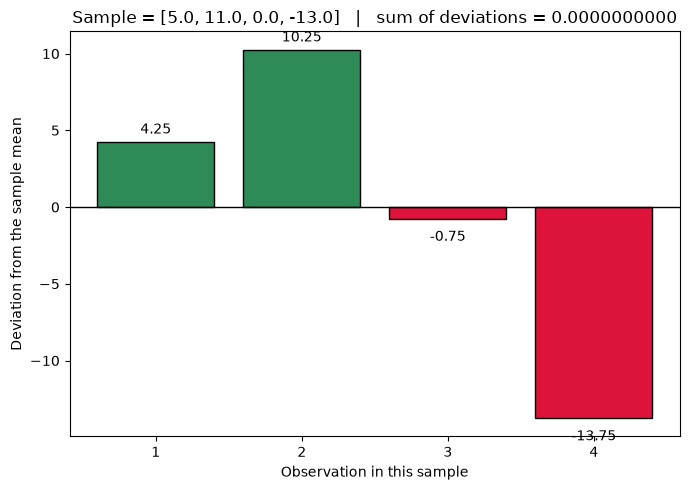

In [15]:
demo_sample = combos_2d[0]
demo_mean = np.mean(demo_sample)
demo_devs = demo_sample - demo_mean
demo_colors = ["seagreen" if d >= 0 else "crimson" for d in demo_devs]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(range(1, n + 1), demo_devs, color=demo_colors, edgecolor="black")
ax.axhline(0, color="black", linewidth=1)

for i, d in enumerate(demo_devs):
    ax.annotate(f"{d:.2f}", (i + 1, d), textcoords="offset points",
                xytext=(0, 6 if d >= 0 else -16), ha="center", fontsize=10)

ax.set_xticks(range(1, n + 1))
ax.set_xlabel("Observation in this sample")
ax.set_ylabel("Deviation from the sample mean")
ax.set_title(f"Sample = {demo_sample.tolist()}   |   sum of deviations = {np.sum(demo_devs):.10f}")
plt.tight_layout()
plt.show()

The bars land above and below zero, but it's easy for "they cancel out exactly" to get lost just glancing at four disconnected bars. Let's trace the same deviations, in the same order, as a running total instead - a waterfall chart, where each step picks up exactly where the previous one left off. The colors carry over directly: green steps are the same rises you see above, red steps are the same drops.

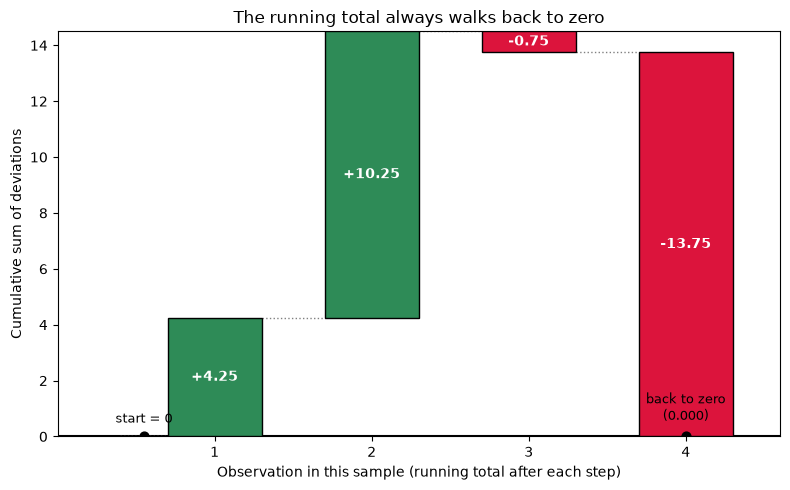

In [19]:
cum = np.concatenate(([0.0], np.cumsum(demo_devs)))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n):
    start, end = cum[i], cum[i + 1]
    d = demo_devs[i]
    color = "seagreen" if d >= 0 else "crimson"
    ax.bar(i + 1, end - start, bottom=start, color=color, edgecolor="black", width=0.6, zorder=3)
    ax.annotate(f"{d:+.2f}", (i + 1, (start + end) / 2), ha="center", va="center",
                fontsize=10, color="white", fontweight="bold", zorder=4)
    if i < n - 1:
        ax.plot([i + 1.3, i + 2 - 0.3], [end, end], linestyle=":", color="gray", linewidth=1, zorder=2)

ax.plot([0.4, 0.7], [0, 0], linestyle=":", color="gray", linewidth=1, zorder=2)
ax.scatter([0.55], [0], color="black", zorder=5, s=40)
ax.annotate("start = 0", (0.55, 0), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

ax.scatter([n], [cum[-1]], color="black", zorder=5, s=40)
ax.annotate(f"back to zero\n({cum[-1]:.3f})", (n, cum[-1]), textcoords="offset points",
            xytext=(0, 12), ha="center", fontsize=9)

ax.axhline(0, color="black", linewidth=1.5, zorder=1)
ax.set_xticks(range(1, n + 1))
ax.set_xlabel("Observation in this sample (running total after each step)")
ax.set_ylabel("Cumulative sum of deviations")
ax.set_title("The running total always walks back to zero")
ax.set_xlim(0, n + 0.6)
plt.tight_layout()
plt.show()

The walk starts at zero, takes four steps - green up, red down, in whatever mix this sample happens to produce - and lands exactly back on zero. Not approximately: exactly, every time, for every possible sample. This is the constraint that costs us a degree of freedom.

Think of it this way: if you're told the sample mean and any $n-1$ of the deviations, you can always figure out the last one - it's whatever value makes everything sum to zero. It isn't free to vary independently; it's *determined* by the others. Only $n-1$ of the deviations carry genuinely new information. Let's demonstrate that directly by freely choosing $n-1$ deviations at random and showing the last one is forced.

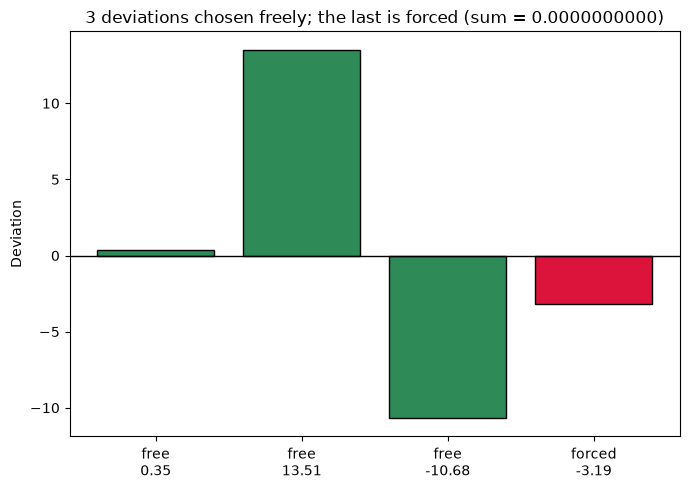

In [14]:
rng = np.random.default_rng(1)
free_devs = rng.uniform(-15, 15, size=n - 1)
forced_dev = -np.sum(free_devs)
all_devs = np.append(free_devs, forced_dev)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["seagreen"] * (n - 1) + ["crimson"]
ax.bar(range(1, n + 1), all_devs, color=colors, edgecolor="black")
ax.axhline(0, color="black", linewidth=1)

labels = [f"free\n{v:.2f}" for v in free_devs] + [f"forced\n{forced_dev:.2f}"]
ax.set_xticks(range(1, n + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("Deviation")
ax.set_title(f"{n - 1} deviations chosen freely; the last is forced (sum = {np.sum(all_devs):.10f})")
plt.tight_layout()
plt.show()

We picked the first 3 deviations completely at random - nothing constrained them. But the 4th (in red) had no freedom at all: it was whatever value made the total zero. Out of $n=4$ numbers, only $n - 1 = 3$ carried independent information. That's what **degrees of freedom** means here: the number of values in a calculation that are actually free to vary.

This is precisely why dividing by $n$ underestimates variance: the naive formula treats all $n$ squared deviations as if they were $n$ independent pieces of evidence about spread, but one of them is always secretly determined by the rest - because we used the *sample's own mean* (not the true population mean) as the center. That built-in redundancy is exactly the mechanism from Part 4: it's what lets the sample mean minimize the sample's own SSD in the first place, and it's what makes the sum of squared deviations a little smaller, on average, than it "should" be. Dividing by $n - 1$ instead of $n$ rescales the sum of squared deviations to account for that lost degree of freedom - and the exhaustive experiment above confirms it lands, on average, much closer to the true population variance.

**That's Bessel's correction, from the ground up:**
- Every possible sample of size $n$ shows the same pattern: divide-by-n undershoots the true population variance, divide-by-(n-1) doesn't (Parts 2-3).
- The sample mean minimizes squared deviations *for the data used to compute it* - which is exactly why it slightly understates spread relative to the true center, and exactly why the naive estimator is biased downward (Part 4).
- That understatement traces to a single lost degree of freedom: once the mean is estimated from the sample, only $n-1$ deviations are free to vary. Dividing by $n-1$ instead of $n$ corrects for precisely that (Part 5).